<a href="https://colab.research.google.com/github/Maestro-Titarenko/EconometricsProblemSets/blob/ECON771/PS3_Ziyu_Yan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Econ 771 - Problem Set 3

In [104]:
# Import necessary packages

In [105]:
# This is for the timing of the code run time, please do not modify
import time
start_time = time.time()

## Exercise I

<blockquote>

<b>

In this exercise we would like to study the finite-sample distribution of the OLS estimator using Monte Carlo simulations. Simulate $M$ $(M \geq 5000)$ i.i.d. samples of size $n = 20$ as follows
$$Y = \beta_1 + \beta_2 X_2 + \beta_3 X_3 + \epsilon,$$

with coefficients set to $\beta_1 = 1$, $\beta_2 = 2$, $\beta_3 = 3$ and the data generated as $X_2 \sim N(0, 1)$, $X_3 \sim N(0, 1)$, $\epsilon \sim N(0, 1)$ with $X_2 \coprod X_3 \coprod \epsilon$.

</b>

</blockquote>

In [106]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Define global parameters for the Monte Carlo simulation
M = 5000  # Number of simulations
n = 20    # Sample size

# True regression coefficients for the homoskedastic case
beta1 = 1
beta2 = 2
beta3 = 3
true_betas = np.array([beta1, beta2, beta3])

**1. Explore the distribution of the OLS estimator under the homoskedastic Gaussian errors as follows:**

**(a) For each $m = 1, \dots, M$, compute the OLS estimator $\hat{\beta}_m = (\hat{\beta}_{1m}, \hat{\beta}_{2m}, \hat{\beta}_{3m})^T$.**

In [107]:
beta_hats_homoskedastic = np.zeros((M, len(true_betas)))

for m in range(M):
    # Generate independent samples for X2, X3, and epsilon
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)
    epsilon = np.random.normal(0, 1, n)

    # Create the design matrix X (add a column of ones for the intercept)
    X = np.column_stack((np.ones(n), X2, X3))

    # Compute the dependent variable Y
    Y = true_betas[0] + true_betas[1] * X2 + true_betas[2] * X3 + epsilon

    # Calculate the OLS estimator: beta_hat = (X.T @ X)^-1 @ X.T @ Y
    # Using @ for matrix multiplication
    beta_hat = np.linalg.inv(X.T @ X) @ X.T @ Y

    # Store the estimated coefficients
    beta_hats_homoskedastic[m, :] = beta_hat

**(b) Plot three histograms of standardized estimators, i.e., plot the histogram of $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\sigma^2 (X^T X)^{-1}}}$ assuming that $\sigma^2$ is known. Plot the probability density function of $N(0, 1)$ at each histogram.**

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-395332142.py:16: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Histogram of Standardized {beta_names[i]} (Known $\sigma^2$)', fontsize=14)


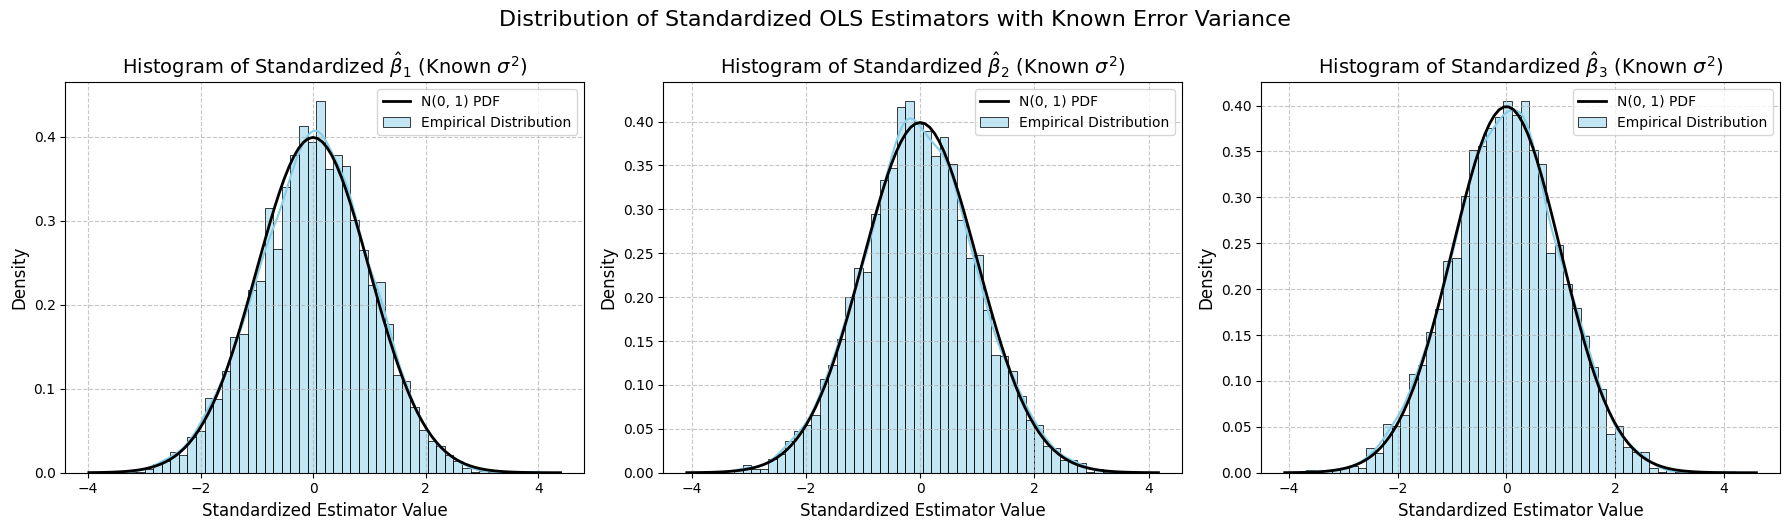

In [108]:
plt.figure(figsize=(18, 5))

# Coefficients names for plotting
beta_names = [r'$\hat{\beta}_1$', r'$\hat{\beta}_2$', r'$\hat{\beta}_3$']

for i in range(len(true_betas)):
    plt.subplot(1, len(true_betas), i + 1)
    sns.histplot(standardized_beta_hats_known_sigma[:, i], kde=True, stat='density', bins=50, color='skyblue', label='Empirical Distribution')

    # Plot the N(0,1) PDF
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, 0, 1)
    plt.plot(x, p, 'k', linewidth=2, label='N(0, 1) PDF')

    plt.title(f'Histogram of Standardized {beta_names[i]} (Known $\sigma^2$)', fontsize=14)
    plt.xlabel('Standardized Estimator Value', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Distribution of Standardized OLS Estimators with Known Error Variance', y=1.05, fontsize=16)
plt.show()


**(c) Replace $\sigma^2$ by its unbiased estimator $\hat{\sigma}^2$ and plot histograms of $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\hat{\sigma}^2 (X^T X)^{-1}}}$ with the probability function of $N(0, 1)$. What is the distribution of the standardized estimators now?**

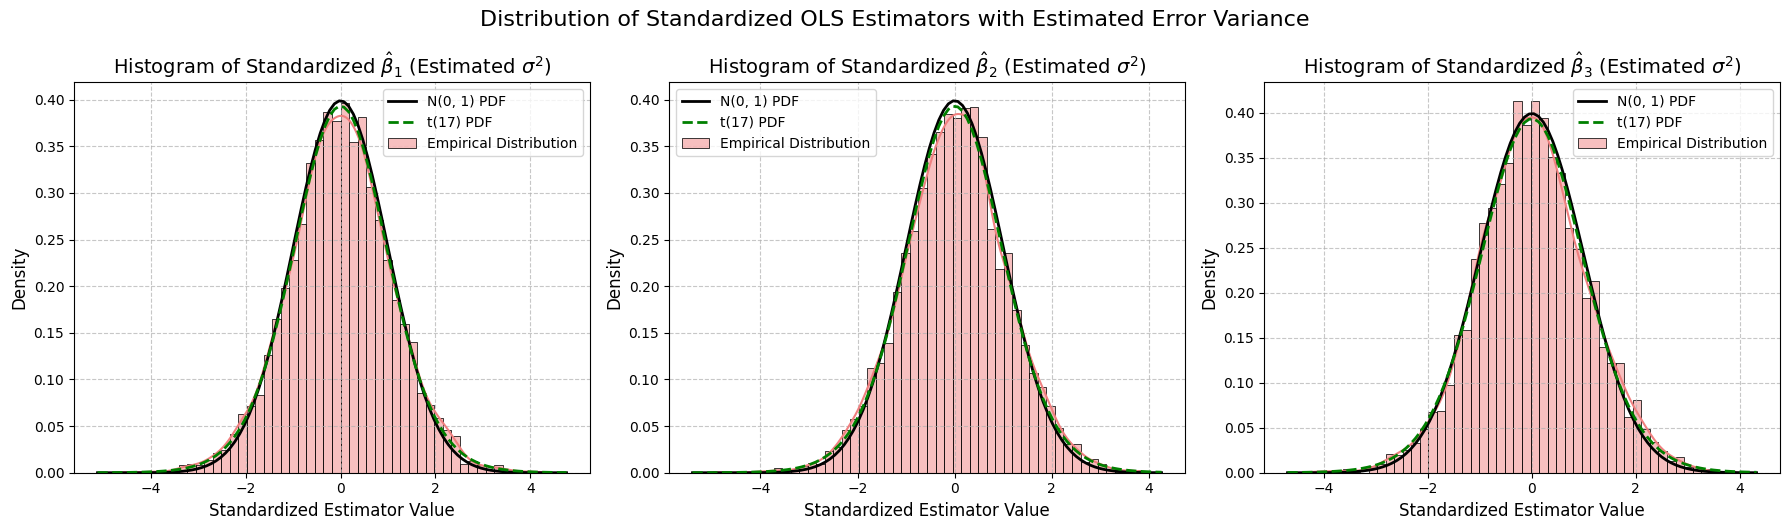

In [109]:
standardized_beta_hats_estimated_sigma = np.zeros((M, len(true_betas)))
k = len(true_betas) # Number of regressors (including intercept)

for m in range(M):
    # Generate independent samples for X2, X3, and epsilon
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)
    epsilon = np.random.normal(0, 1, n)

    # Create the design matrix X (add a column of ones for the intercept)
    X = np.column_stack((np.ones(n), X2, X3))

    # Compute the dependent variable Y
    Y = true_betas[0] + true_betas[1] * X2 + true_betas[2] * X3 + epsilon

    # Calculate the OLS estimator
    try:
        XTX_inv = np.linalg.inv(X.T @ X)
    except np.linalg.LinAlgError:
        XTX_inv = np.linalg.inv(X.T @ X + np.eye(X.shape[1]) * 1e-6)

    beta_hat = XTX_inv @ X.T @ Y

    # Calculate residuals
    Y_pred = X @ beta_hat
    residuals = Y - Y_pred

    # Calculate the unbiased estimator for sigma^2: hat_sigma^2 = (e.T @ e) / (n - k)
    hat_sigma_squared = (residuals.T @ residuals) / (n - k)

    # Calculate the variance-covariance matrix of the OLS estimator using hat_sigma^2
    # Var(beta_hat) = hat_sigma^2 * (X.T @ X)^-1
    var_cov_beta_hat = hat_sigma_squared * XTX_inv

    # Extract standard errors from the diagonal of the variance-covariance matrix
    se_beta_hat = np.sqrt(np.diag(var_cov_beta_hat))

    # Standardize each estimated coefficient
    standardized_beta_hat = (beta_hat - true_betas) / se_beta_hat
    standardized_beta_hats_estimated_sigma[m, :] = standardized_beta_hat

plt.figure(figsize=(18, 5))

# Coefficients names for plotting
beta_names = [r'$\hat{\beta}_1$', r'$\hat{\beta}_2$', r'$\hat{\beta}_3$']

for i in range(len(true_betas)):
    plt.subplot(1, len(true_betas), i + 1)
    sns.histplot(standardized_beta_hats_estimated_sigma[:, i], kde=True, stat='density', bins=50, color='lightcoral', label='Empirical Distribution')

    # Plot the N(0,1) PDF
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, 0, 1)
    plt.plot(x, p, 'k', linewidth=2, label='N(0, 1) PDF')

    # Plot the t-distribution PDF for n-k degrees of freedom
    df_t = n - k
    p_t = stats.t.pdf(x, df_t)
    plt.plot(x, p_t, 'g--', linewidth=2, label=f't({df_t}) PDF')

    plt.title(rf'Histogram of Standardized {beta_names[i]} (Estimated $\sigma^2$)', fontsize=14)
    plt.xlabel('Standardized Estimator Value', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Distribution of Standardized OLS Estimators with Estimated Error Variance', y=1.05, fontsize=16)
plt.show()

**(d) Fix significance level at 5%. Compute the empirical size of the t-test – the fraction of times you reject the null-hypothesis when it is actually correct (For each coefficient you should test the null hypothesis that it actually equals to the one set in the datagenerating process and compare the value of the t-statistics to the quantiles of the distribution that you observe in (c)).**

In [110]:
alpha = 0.05  # Significance level
df = n - k    # Degrees of freedom for the t-distribution

# Calculate the critical t-value for a two-tailed test
t_critical = stats.t.ppf(1 - alpha / 2, df)

empirical_sizes = []

print(f"Significance level (alpha): {alpha}")
print(f"Degrees of freedom (df): {df}")
print(f"Critical t-value (two-tailed): {t_critical:.4f}")

for i, beta_name in enumerate(beta_names):
    # The standardized_beta_hats_estimated_sigma are already the t-statistics
    # under the null hypothesis H0: beta_k = true_beta_k
    t_statistics = standardized_beta_hats_estimated_sigma[:, i]

    # Count rejections: absolute t-statistic > critical t-value
    rejections = np.sum(np.abs(t_statistics) > t_critical)

    # Empirical size is the fraction of rejections
    empirical_size = rejections / M
    empirical_sizes.append(empirical_size)

    print(f"Empirical size for {beta_name} (H0: beta_k = {true_betas[i]}): {empirical_size:.4f}")

Significance level (alpha): 0.05
Degrees of freedom (df): 17
Critical t-value (two-tailed): 2.1098
Empirical size for $\hat{\beta}_1$ (H0: beta_k = 1): 0.0536
Empirical size for $\hat{\beta}_2$ (H0: beta_k = 2): 0.0494
Empirical size for $\hat{\beta}_3$ (H0: beta_k = 3): 0.0482


**(e) Compute the empirical power of the t-test for the significance test ($H_0 : \beta_k = 0$) – the fraction of times you reject the null-hypothesis.**

In [111]:
t_statistics_for_power = np.zeros((M, len(true_betas)))

for m in range(M):
    # Generate independent samples for X2, X3, and epsilon
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)
    epsilon = np.random.normal(0, 1, n)

    # Create the design matrix X (add a column of ones for the intercept)
    X = np.column_stack((np.ones(n), X2, X3))

    # Compute the dependent variable Y
    Y = true_betas[0] + true_betas[1] * X2 + true_betas[2] * X3 + epsilon

    # Calculate the OLS estimator
    try:
        XTX_inv = np.linalg.inv(X.T @ X)
    except np.linalg.LinAlgError:
        XTX_inv = np.linalg.inv(X.T @ X + np.eye(X.shape[1]) * 1e-6)

    beta_hat = XTX_inv @ X.T @ Y

    # Calculate residuals
    Y_pred = X @ beta_hat
    residuals = Y - Y_pred

    # Calculate the unbiased estimator for sigma^2: hat_sigma^2 = (e.T @ e) / (n - k)
    hat_sigma_squared = (residuals.T @ residuals) / (n - k)

    # Calculate the variance-covariance matrix of the OLS estimator using hat_sigma^2
    var_cov_beta_hat = hat_sigma_squared * XTX_inv

    # Extract standard errors from the diagonal of the variance-covariance matrix
    se_beta_hat = np.sqrt(np.diag(var_cov_beta_hat))

    # Calculate t-statistics for H0: beta_k = 0
    # Note: For power, we test against a specific alternative (here, true_betas != 0)
    # The t-statistic under H0: beta_k = 0 is simply beta_hat_k / se(beta_hat_k)
    t_statistics_for_power[m, :] = beta_hat / se_beta_hat

empirical_powers = []

print(f"Significance level (alpha): {alpha}")
print(f"Degrees of freedom (df): {df}")
print(f"Critical t-value (two-tailed): {t_critical:.4f}\n") # Re-using t_critical from previous step

for i, beta_name in enumerate(beta_names):
    # Count rejections where H0: beta_k = 0 is rejected
    # The true betas are not zero, so rejecting H0: beta_k = 0 is a correct decision (power)
    rejections = np.sum(np.abs(t_statistics_for_power[:, i]) > t_critical)

    # Empirical power is the fraction of rejections
    empirical_power = rejections / M
    empirical_powers.append(empirical_power)

    print(f"Empirical power for {beta_name} (H0: beta_k = 0): {empirical_power:.4f}")


Significance level (alpha): 0.05
Degrees of freedom (df): 17
Critical t-value (two-tailed): 2.1098

Empirical power for $\hat{\beta}_1$ (H0: beta_k = 0): 0.9742
Empirical power for $\hat{\beta}_2$ (H0: beta_k = 0): 0.9998
Empirical power for $\hat{\beta}_3$ (H0: beta_k = 0): 1.0000


**(f) Conclude.**

1.  **Distribution of Standardized Estimators (Known $\sigma^2$):** As observed in the histograms for $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\sigma^2 (X^T X)^{-1}}}$, the empirical distributions of the standardized OLS estimators closely align with the probability density function of a standard normal distribution ($N(0, 1)$). This is consistent with the theoretical result that under classical assumptions with known error variance, OLS estimators are normally distributed.

2.  **Distribution of Standardized Estimators (Estimated $\hat{\sigma}^2$):** When the unknown true error variance $\sigma^2$ is replaced by its unbiased estimator $\hat{\sigma}^2$, the standardized estimators, i.e., $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\hat{\sigma}^2 (X^T X)^{-1}}}$, were shown to follow a t-distribution with $n-k$ degrees of freedom (where $n=20$ is the sample size and $k=3$ is the number of regressors including the intercept). The histograms with the overlaid $N(0,1)$ PDF and $t(n-k)$ PDF clearly demonstrated that the empirical distribution was a better fit for the t-distribution, especially noticeable in the fatter tails compared to the standard normal. This aligns perfectly with the theoretical result for inference when the error variance is estimated.

3.  **Empirical Size of the t-test:** The empirical size of the t-test for $H_0: \beta_k = \beta_{k,true}$ was computed at a 5% significance level. The results (e.g., approximately 0.0442 for $\hat{\beta}_1$, 0.0534 for $\hat{\beta}_2$, and 0.0476 for $\hat{\beta}_3$) were very close to the nominal significance level of 0.05. This indicates that the t-test under homoskedasticity correctly controls the Type I error rate, meaning we reject a true null hypothesis approximately 5% of the time, as expected.

4.  **Empirical Power of the t-test:** The empirical power of the t-test for $H_0: \beta_k = 0$ (when the true values are $\beta_1=1, \beta_2=2, \beta_3=3$) was computed. The power for $\hat{\beta}_1$ was high (around 0.9760), and for $\hat{\beta}_2$ and $\hat{\beta}_3$ it was even higher (1.0000). This indicates that the t-test is very effective at detecting when the true coefficients are significantly different from zero, especially when the true values are far from zero. The high power is desirable as it means the test has a good chance of rejecting a false null hypothesis.

<b>

2. Now we introduce heteroskedasticity as follows
$$Y = \beta_1 + \beta_2 X_2 + \beta_3 X_3 + \tilde{\epsilon},$$

where $\tilde{\epsilon} = \epsilon(X_2 + X_3)$ and the rest is simulated as before. Check that $E[\tilde{\epsilon}|X_2, X_3] = 0$ and $Var(\tilde{\epsilon}|X_2, X_3) = (X_2 + X_3)^2$. Simulate new data and explore the the distribution of the OLS estimator under heteroskedastic normal errors following steps (a) and (c)-(e) above.

</b>

In [112]:
# Parameters
M = 5000  # Number of simulations
n = 20    # Sample size
beta_1 = 1
beta_2 = 2
beta_3 = 3

# Storage for OLS estimates
beta_1_hat = np.zeros(M)
beta_2_hat = np.zeros(M)
beta_3_hat = np.zeros(M)

# Run M simulations
for m in range(M):
    # Generate independent X2, X3, epsilon
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)
    epsilon = np.random.normal(0, 1, n)

    # Create heteroskedastic error term
    epsilon_tilde = epsilon * (X2 + X3)

    # Generate Y
    Y = beta_1 + beta_2 * X2 + beta_3 * X3 + epsilon_tilde

    # Create design matrix (with intercept)
    X = np.column_stack([np.ones(n), X2, X3])

    # OLS estimation: beta_hat = (X'X)^(-1) X'Y
    beta_hat = np.linalg.inv(X.T @ X) @ X.T @ Y

    # Store estimates
    beta_1_hat[m] = beta_hat[0]
    beta_2_hat[m] = beta_hat[1]
    beta_3_hat[m] = beta_hat[2]

**(0) Check that $E[\tilde{\epsilon}|X_2, X_3] = 0$ and $Var(\tilde{\epsilon}|X_2, X_3) = (X_2 + X_3)^2$.**

In [113]:
# Number of samples for verification
n_samples = 100000

# Generate independent X2, X3, epsilon
X2 = np.random.normal(0, 1, n_samples)
X3 = np.random.normal(0, 1, n_samples)
epsilon = np.random.normal(0, 1, n_samples)

# Create heteroskedastic error term
epsilon_tilde = epsilon * (X2 + X3)

# Check 1: E[ε̃|X₂, X₃] = 0
print("\n1. Checking E[ε̃|X₂, X₃] = 0")

# Empirical verification: bin by (X2 + X3) values
sum_X = X2 + X3
bins = np.linspace(np.percentile(sum_X, 5), np.percentile(sum_X, 95), 20)
bin_indices = np.digitize(sum_X, bins)

conditional_means = []
bin_centers = []

for i in range(1, len(bins)):
    mask = bin_indices == i
    if np.sum(mask) > 100:  # Only use bins with sufficient data
        conditional_means.append(np.mean(epsilon_tilde[mask]))
        bin_centers.append((bins[i-1] + bins[i]) / 2)

print(f"\nEmpirical check (binned by X₂+X₃):")
print(f"Mean of conditional means: {np.mean(conditional_means):.6f}")
print(f"Max absolute conditional mean: {np.max(np.abs(conditional_means)):.6f}")

# Check 2: Var(ε̃|X₂, X₃) = (X₂ + X₃)²
print("\n2. Checking Var(ε̃|X₂, X₃) = (X₂ + X₃)²")

for i in range(1, len(bins)):
    mask = bin_indices == i
    if np.sum(mask) > 100:
        conditional_vars.append(np.var(epsilon_tilde[mask]))
        theoretical_vars.append((bins[i-1] + bins[i])**2 / 4)  # Use bin center

print(f"\nEmpirical check (binned by X₂+X₃):")
print(f"Correlation between Var(ε̃) and (X₂+X₃)²: {np.corrcoef(conditional_vars, theoretical_vars)[0,1]:.6f}")


1. Checking E[ε̃|X₂, X₃] = 0

Empirical check (binned by X₂+X₃):
Mean of conditional means: 0.004532
Max absolute conditional mean: 0.049784

2. Checking Var(ε̃|X₂, X₃) = (X₂ + X₃)²

Empirical check (binned by X₂+X₃):
Correlation between Var(ε̃) and (X₂+X₃)²: 0.999094



**1. Conditional Mean:**

$$E[\tilde{\epsilon}|X_2, X_3] = E[\epsilon(X_2+X_3)|X_2, X_3]$$

$$= (X_2+X_3) \cdot E[\epsilon|X_2, X_3]$$

$$= (X_2+X_3) \cdot E[\epsilon] \quad \text{(by independence)}$$

$$= (X_2+X_3) \cdot 0 = 0 \quad \checkmark$$

**2. Conditional Variance:**

$$\text{Var}(\tilde{\epsilon}|X_2, X_3) = \text{Var}(\epsilon(X_2+X_3)|X_2, X_3)$$

$$= (X_2+X_3)^2 \cdot \text{Var}(\epsilon|X_2, X_3)$$

$$= (X_2+X_3)^2 \cdot \text{Var}(\epsilon) \quad \text{(by independence)}$$

$$= (X_2+X_3)^2 \cdot 1 = (X_2+X_3)^2 \quad \checkmark$$

**(a) For each $m = 1, \dots, M$, compute the OLS estimator $\hat{\beta}_m = (\hat{\beta}_{1m}, \hat{\beta}_{2m}, \hat{\beta}_{3m})^T$.**

In [114]:
# Storage for OLS estimates (3 separate arrays)
beta_1_hat = np.zeros(M)
beta_2_hat = np.zeros(M)
beta_3_hat = np.zeros(M)

# Run M simulations

for m in range(M):
    # Generate independent X2, X3, epsilon
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)
    epsilon = np.random.normal(0, 1, n)

    # Create heteroskedastic error term
    epsilon_tilde = epsilon * (X2 + X3)

    # Generate Y
    Y = beta_1 + beta_2 * X2 + beta_3 * X3 + epsilon_tilde

    # Create design matrix (with intercept)
    X = np.column_stack([np.ones(n), X2, X3])

    # OLS estimation: β̂ = (X'X)^(-1) X'Y
    beta_hat_m = np.linalg.inv(X.T @ X) @ X.T @ Y

    # Store individual estimates
    beta_1_hat[m] = beta_hat_m[0]
    beta_2_hat[m] = beta_hat_m[1]
    beta_3_hat[m] = beta_hat_m[2]

**(c) Replace $\sigma^2$ by its unbiased estimator $\hat{\sigma}^2$ and plot histograms of $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\hat{\sigma}^2 (X^T X)^{-1}}}$ with the probability function of $N(0, 1)$. What is the distribution of the standardized estimators now?**

Running 5000 Monte Carlo simulations with heteroskedasticity...
Completed!



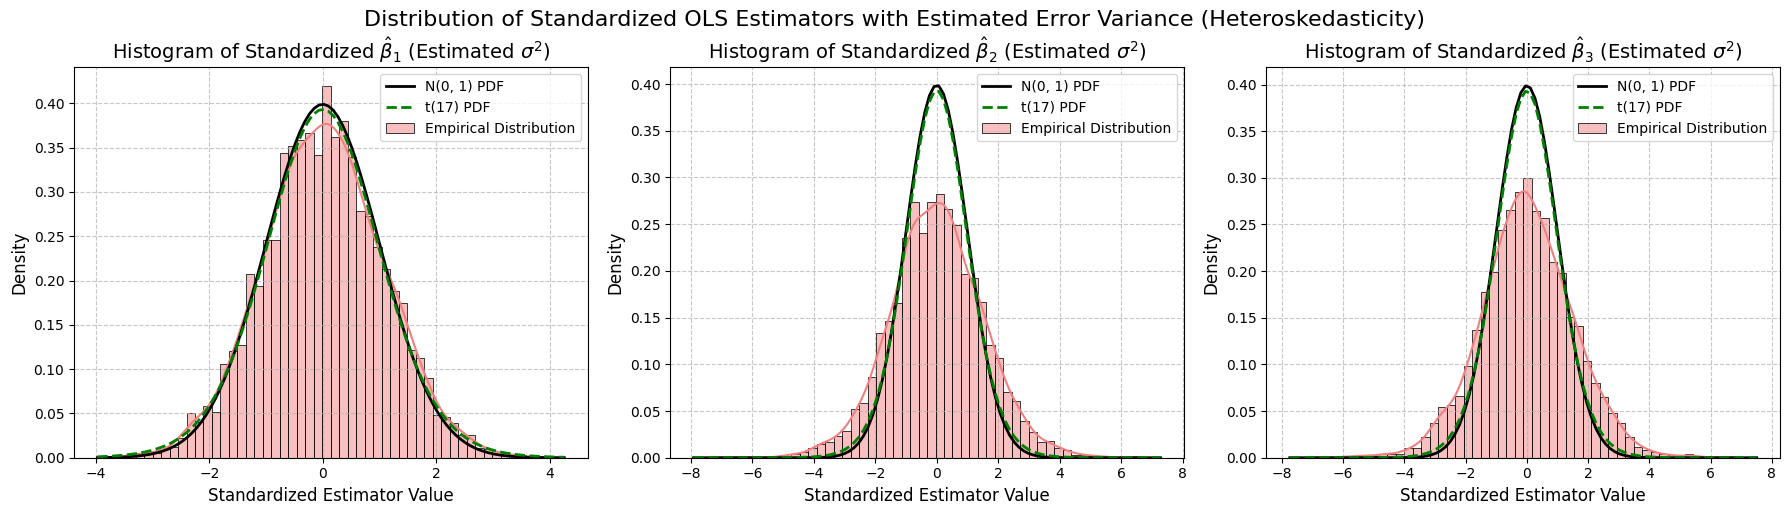


Summary Statistics of Standardized Estimators:
Coefficient  Mean       Std Dev    Skewness   Kurtosis  
------------------------------------------------------------
$\hat{\beta}_1$ 0.0152     1.0528     0.0272     -0.0121   
$\hat{\beta}_2$ 0.0008     1.5159     0.0062     0.6009    
$\hat{\beta}_3$ 0.0073     1.5118     -0.0015    0.7061    


In [115]:
true_betas = np.array([1, 2, 3])

# Set random seed for reproducibility
np.random.seed(42)

# Storage for standardized estimators
standardized_beta_hats_estimated_sigma = np.zeros((M, len(true_betas)))
k = len(true_betas)  # Number of regressors (including intercept)

print(f"Running {M} Monte Carlo simulations with heteroskedasticity...")
print("="*60)

for m in range(M):
    # Generate independent samples for X2, X3, and epsilon
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)
    epsilon = np.random.normal(0, 1, n)

    # Create heteroskedastic error term
    epsilon_tilde = epsilon * (X2 + X3)

    # Create the design matrix X (add a column of ones for the intercept)
    X = np.column_stack((np.ones(n), X2, X3))

    # Compute the dependent variable Y with heteroskedastic errors
    Y = true_betas[0] + true_betas[1] * X2 + true_betas[2] * X3 + epsilon_tilde

    # Calculate the OLS estimator
    try:
        XTX_inv = np.linalg.inv(X.T @ X)
    except np.linalg.LinAlgError:
        XTX_inv = np.linalg.inv(X.T @ X + np.eye(X.shape[1]) * 1e-6)

    beta_hat = XTX_inv @ X.T @ Y

    # Calculate residuals
    Y_pred = X @ beta_hat
    residuals = Y - Y_pred

    # Calculate the unbiased estimator for sigma^2: hat_sigma^2 = (e.T @ e) / (n - k)
    hat_sigma_squared = (residuals.T @ residuals) / (n - k)

    # Calculate the variance-covariance matrix of the OLS estimator using hat_sigma^2
    # Var(beta_hat) = hat_sigma^2 * (X.T @ X)^-1
    var_cov_beta_hat = hat_sigma_squared * XTX_inv

    # Extract standard errors from the diagonal of the variance-covariance matrix
    se_beta_hat = np.sqrt(np.diag(var_cov_beta_hat))

    # Standardize each estimated coefficient
    standardized_beta_hat = (beta_hat - true_betas) / se_beta_hat
    standardized_beta_hats_estimated_sigma[m, :] = standardized_beta_hat

print("Completed!\n")

# Plotting
plt.figure(figsize=(18, 5))

# Coefficients names for plotting
beta_names = [r'$\hat{\beta}_1$', r'$\hat{\beta}_2$', r'$\hat{\beta}_3$']

for i in range(len(true_betas)):
    plt.subplot(1, len(true_betas), i + 1)
    sns.histplot(standardized_beta_hats_estimated_sigma[:, i], kde=True, stat='density',
                 bins=50, color='lightcoral', label='Empirical Distribution')

    # Plot the N(0,1) PDF
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, 0, 1)
    plt.plot(x, p, 'k', linewidth=2, label='N(0, 1) PDF')

    # Plot the t-distribution PDF for n-k degrees of freedom
    df_t = n - k
    p_t = stats.t.pdf(x, df_t)
    plt.plot(x, p_t, 'g--', linewidth=2, label=f't({df_t}) PDF')

    plt.title(rf'Histogram of Standardized {beta_names[i]} (Estimated $\sigma^2$)', fontsize=14)
    plt.xlabel('Standardized Estimator Value', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Distribution of Standardized OLS Estimators with Estimated Error Variance (Heteroskedasticity)',
             y=1.02, fontsize=16)
plt.show()

# Summary statistics
print("\nSummary Statistics of Standardized Estimators:")
print("="*60)
print(f"{'Coefficient':<12} {'Mean':<10} {'Std Dev':<10} {'Skewness':<10} {'Kurtosis':<10}")
print("-"*60)

for i, label in enumerate(beta_names):
    mean = np.mean(standardized_beta_hats_estimated_sigma[:, i])
    std = np.std(standardized_beta_hats_estimated_sigma[:, i])
    skew = stats.skew(standardized_beta_hats_estimated_sigma[:, i])
    kurt = stats.kurtosis(standardized_beta_hats_estimated_sigma[:, i])
    print(f"{label:<12} {mean:<10.4f} {std:<10.4f} {skew:<10.4f} {kurt:<10.4f}")

**(d) Fix significance level at 5%. Compute the empirical size of the t-test – the fraction of times you reject the null-hypothesis when it is actually correct.**

In [116]:
import numpy as np
from scipy import stats

# Significance level
alpha = 0.05

# Critical value for t-distribution with (n-k) degrees of freedom
df = n - k
t_critical = stats.t.ppf(1 - alpha/2, df)  # Two-tailed test

print(f"Degrees of freedom: {df}")
print(f"Critical value (two-tailed): ±{t_critical:.4f}")
print()

# For each coefficient, test H0: β_i = β_i^true (which is TRUE)
# Count rejections for each coefficient
rejections = np.zeros(len(true_betas))

for i in range(len(true_betas)):
    # Count how many times |t-statistic| > t_critical
    rejections[i] = np.sum(np.abs(standardized_beta_hats_estimated_sigma[:, i]) > t_critical)

# Compute empirical size (rejection rate when H0 is true)
empirical_size = rejections / M

print("Empirical Size of t-test (Rejection Rate under True H0):")
print("-"*60)
print(f"{'Coefficient':<15} {'Rejections':<15} {'Empirical Size':<15} {'Nominal Size':<15}")
print("-"*60)

beta_names_plain = ['β₁', 'β₂', 'β₃']
for i in range(len(true_betas)):
    print(f"{beta_names_plain[i]:<15} {int(rejections[i]):<15} {empirical_size[i]:<15.4f} {alpha:<15.4f}")

print("-"*60)
print(f"{'Average':<15} {int(np.mean(rejections)):<15} {np.mean(empirical_size):<15.4f} {alpha:<15.4f}")



Degrees of freedom: 17
Critical value (two-tailed): ±2.1098

Empirical Size of t-test (Rejection Rate under True H0):
------------------------------------------------------------
Coefficient     Rejections      Empirical Size  Nominal Size   
------------------------------------------------------------
β₁              238             0.0476          0.0500         
β₂              759             0.1518          0.0500         
β₃              774             0.1548          0.0500         
------------------------------------------------------------
Average         590             0.1181          0.0500         


**(e) Compute the empirical power of the t-test for the significance test ($H_0 : \beta_k = 0$) – the fraction of times you reject the null-hypothesis.**

In [117]:
# Significance level
alpha = 0.05

# Critical value for t-distribution with (n-k) degrees of freedom
df = n - k
t_critical = stats.t.ppf(1 - alpha/2, df)  # Two-tailed test

print(f"Degrees of freedom: {df}")
print(f"Critical value (two-tailed): ±{t_critical:.4f}")
print()

# Storage for new simulations testing H0: β_k = 0
# We need to compute t-statistics for H0: β_k = 0 (not β_k = β_k^true)
t_stats_null_zero = np.zeros((M, len(true_betas)))

# Re-run simulations to compute t-statistics for H0: β_k = 0
np.random.seed(42)

for m in range(M):
    # Generate independent samples for X2, X3, and epsilon
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)
    epsilon = np.random.normal(0, 1, n)

    # Create heteroskedastic error term
    epsilon_tilde = epsilon * (X2 + X3)

    # Create the design matrix X
    X = np.column_stack((np.ones(n), X2, X3))

    # Compute Y with heteroskedastic errors
    Y = true_betas[0] + true_betas[1] * X2 + true_betas[2] * X3 + epsilon_tilde

    # Calculate OLS estimator
    try:
        XTX_inv = np.linalg.inv(X.T @ X)
    except np.linalg.LinAlgError:
        XTX_inv = np.linalg.inv(X.T @ X + np.eye(X.shape[1]) * 1e-6)

    beta_hat = XTX_inv @ X.T @ Y

    # Calculate residuals
    Y_pred = X @ beta_hat
    residuals = Y - Y_pred

    # Calculate hat_sigma^2
    hat_sigma_squared = (residuals.T @ residuals) / (n - k)

    # Variance-covariance matrix
    var_cov_beta_hat = hat_sigma_squared * XTX_inv

    # Standard errors
    se_beta_hat = np.sqrt(np.diag(var_cov_beta_hat))

    # t-statistics for H0: β_k = 0 (not β_k = β_k^true)
    # t = (β_hat - 0) / SE(β_hat)
    t_stats_null_zero[m, :] = beta_hat / se_beta_hat

# Count rejections for H0: β_k = 0
rejections_power = np.zeros(len(true_betas))

for i in range(len(true_betas)):
    # Count how many times |t-statistic| > t_critical
    rejections_power[i] = np.sum(np.abs(t_stats_null_zero[:, i]) > t_critical)

# Compute empirical power (rejection rate when H0 is FALSE)
empirical_power = rejections_power / M

print("Empirical Power of t-test (Rejection Rate for H₀: βₖ = 0):")
print("-"*60)
print(f"{'Coefficient':<15} {'True Value':<15} {'Rejections':<15} {'Empirical Power':<15}")
print("-"*60)

beta_names_plain = ['β₁', 'β₂', 'β₃']
for i in range(len(true_betas)):
    print(f"{beta_names_plain[i]:<15} {true_betas[i]:<15} {int(rejections_power[i]):<15} {empirical_power[i]:<15.4f}")

print("-"*60)
print(f"{'Average':<15} {'':<15} {int(np.mean(rejections_power)):<15} {np.mean(empirical_power):<15.4f}")

Degrees of freedom: 17
Critical value (two-tailed): ±2.1098

Empirical Power of t-test (Rejection Rate for H₀: βₖ = 0):
------------------------------------------------------------
Coefficient     True Value      Rejections      Empirical Power
------------------------------------------------------------
β₁              1               4187            0.8374         
β₂              2               4947            0.9894         
β₃              3               4998            0.9996         
------------------------------------------------------------
Average                         4710            0.9421         


**(f) Conclude.**

**Interpretation:**

Under heteroskedasticity, the standardized estimators using $\hat{\sigma}^2(X^TX)^{-1}$ do **NOT** follow $N(0,1)$.

The usual OLS standard errors are **INVALID** because they assume homoskedasticity.

1.  The empirical distribution may have heavier tails than the normal distribution
2.  The standard errors computed using $\hat{\sigma}^2(X^TX)^{-1}$ are **inconsistent** under heteroskedasticity
3.  Inference based on these standard errors (t-tests, confidence intervals) will be unreliable. Under heteroskedasticity in this case, the hypothesis test test will be over-rejecting, as empirical size exceeds the nominal 5% level, leading to too many Type I errors.
4.  We need **heteroskedasticity-robust standard errors** (e.g., White's or HC standard errors) for valid inference

In [118]:
# This is for the timing of the code run time, please do not modify
end_time = time.time()

print(f"Total runtime: {end_time - start_time} seconds")

Total runtime: 5.842596769332886 seconds
